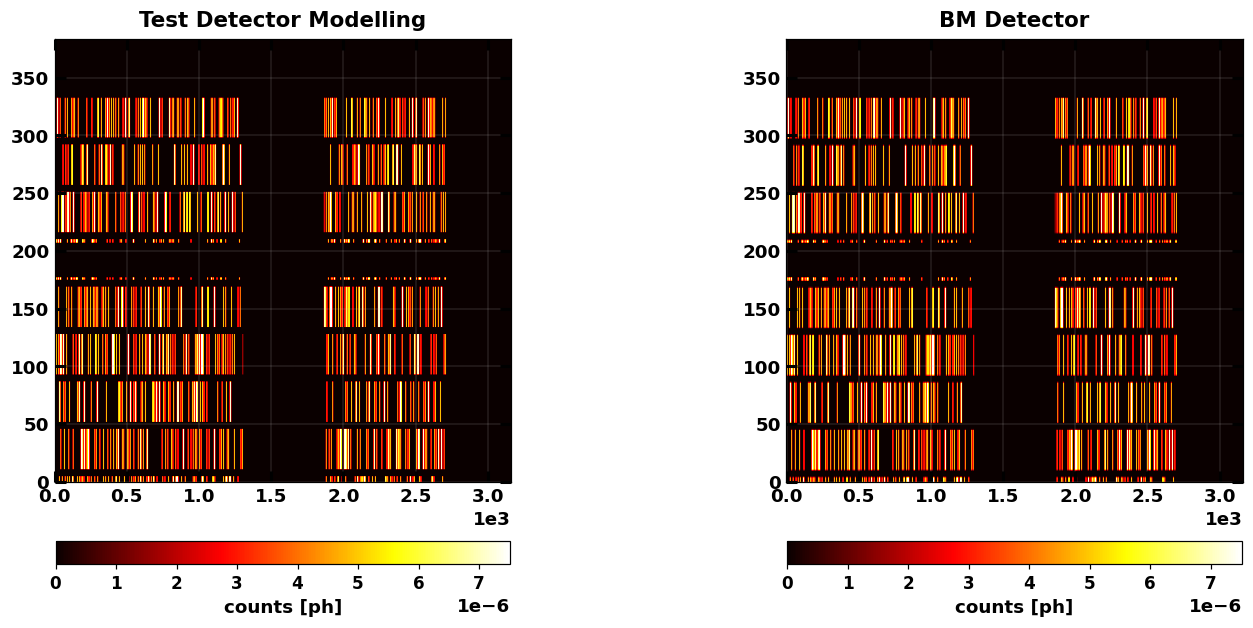

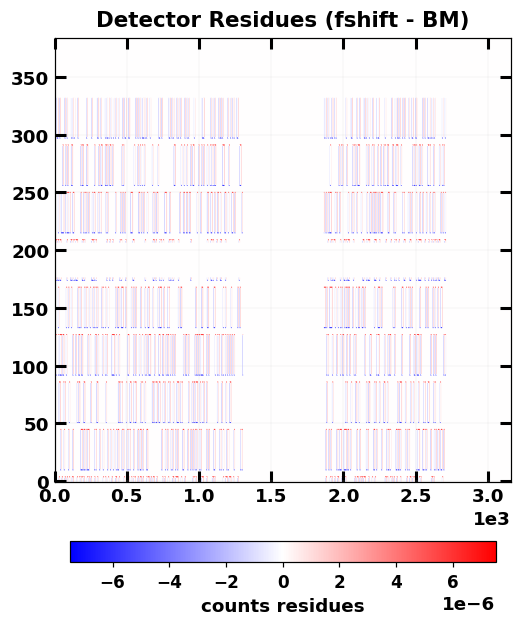

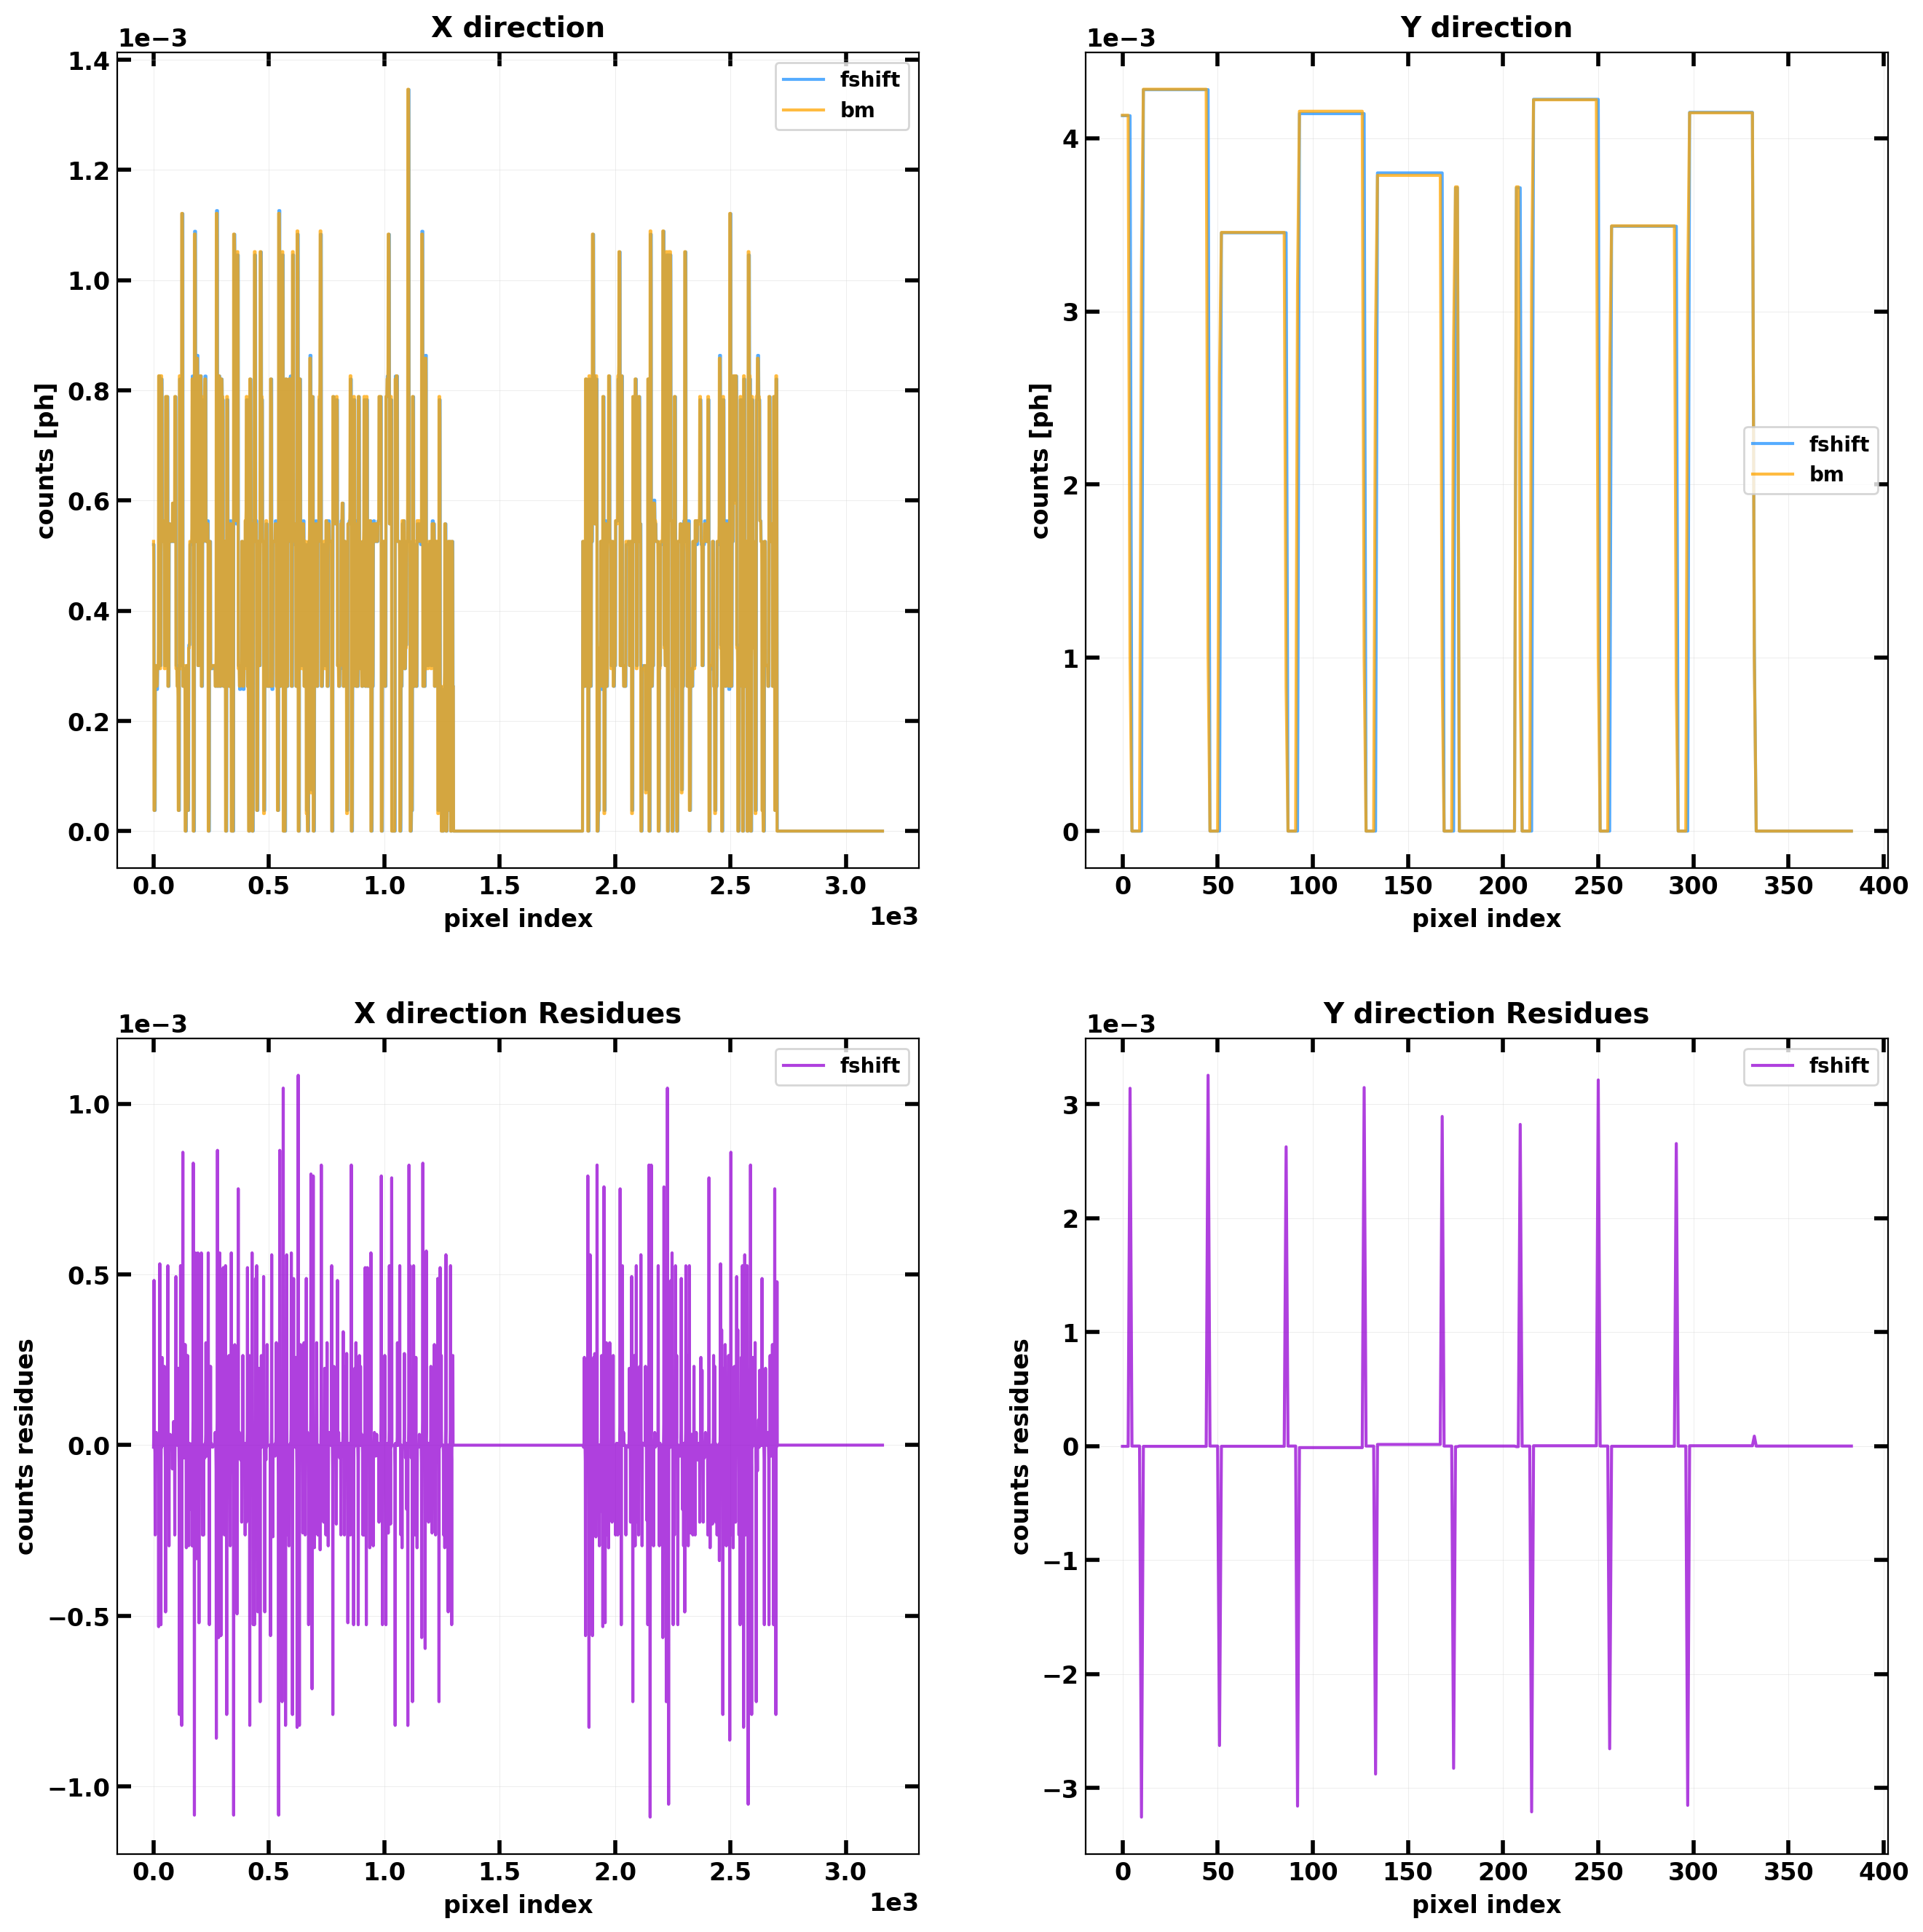

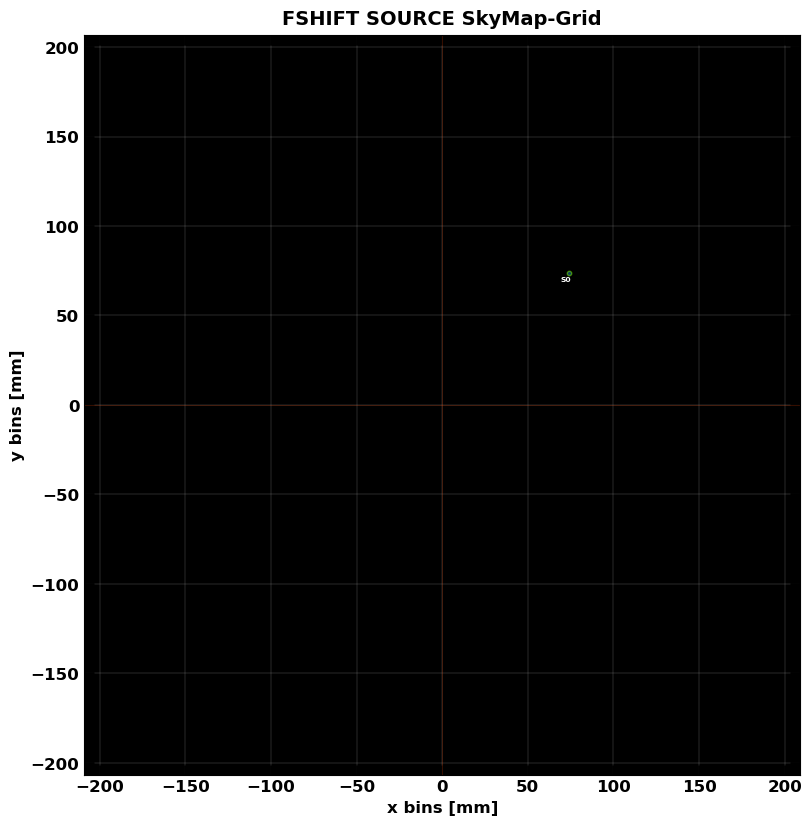

In [ ]:
import numpy as np

from bloodmoon.mask import codedmask
from bloodmoon.coords import angle2shift
from bloodmoon.optim import model_shadowgram as bm_shadowgram

from darksun.types import LogEntry
from darksun.data import create_log
from darksun.show import map4image, image_plot
from darksun.show import map4plot, plot
from darksun.show import skyfield_map

from fract_shift import model_shadowgram


# setup mask and instr effects
basepath = '/mnt/d/PhD_AASS/Coding/Images_fits'
maskpath = f'{basepath}/wfm_mask_summer2021.fits'

UPX, UPY = 5, 1
wfm = codedmask(maskpath, UPX, UPY)
VIGNETTING = False
PSFY = False

ASPECT = (wfm.specs['mask_deltay'] / UPY) / (wfm.specs['mask_deltax'] / UPX)

# source local-frame coords and detector images
shifty, shiftx = (
    angle2shift(wfm, 20),
    angle2shift(wfm, 20),
)

det = model_shadowgram(wfm, shiftx, shifty, VIGNETTING, PSFY)
dmap1 = map4image(
    det,
    title='Test Detector Modelling',
    cbarlabel='counts [ph]',
    cbarloc='bottom',
    img_kwargs={
        'cmap': 'hot',
        'aspect': ASPECT,
    },
)

bm_det = bm_shadowgram(wfm, shiftx, shifty, VIGNETTING, PSFY)
dmap2 = map4image(
    bm_det,
    title='BM Detector',
    cbarlabel='counts [ph]',
    cbarloc='bottom',
    img_kwargs={
        'cmap': 'hot',
        'aspect': ASPECT,
    },
)
image_plot((dmap1, dmap2), ncols=2)

# detectors residuals
res = det - bm_det
LIM = res.max()
dmap_res = map4image(
    res,
    title='Detector Residues (fshift - BM)',
    cbarlabel='counts residues',
    cbarloc='bottom',
    img_kwargs={
        'cmap': 'bwr',
        'aspect': ASPECT,
        'vmin': -LIM,
        'vmax': LIM,
    },
)
image_plot(dmap_res)


# collapse along axes
collapsed_x, collapsed_bmx = map(
    lambda x: np.sum(x, axis=0),
    (det, bm_det),
)
collapsed_y, collapsed_bmy = map(
    lambda x: np.sum(x, axis=1),
    (det, bm_det),
)
dmapx = map4plot(
    arrs=(collapsed_x, collapsed_bmx),
    title='X direction',
    ylabel='counts [ph]',
    xlabel='pixel index',
    labels=('fshift', 'bm'),
    color=('DodgerBlue', 'Orange'),
    #ylim=(0, max(collapsed_x.max(), collapsed_bmx.max())),
)
dmapy = map4plot(
    arrs=(collapsed_y, collapsed_bmy),
    title='Y direction',
    ylabel='counts [ph]',
    xlabel='pixel index',
    labels=('fshift', 'bm'),
    color=('DodgerBlue', 'Orange'),
    #ylim=(0, max(collapsed_y.max(), collapsed_bmy.max())),
)
dmapx_res = map4plot(
    arrs=collapsed_x - collapsed_bmx,
    title='X direction Residues',
    ylabel='counts residues',
    xlabel='pixel index',
    labels=('fshift', 'bm'),
    color=('DarkViolet'),
    #ylim=(-1.5e4, 1.2e4),
)
dmapy_res = map4plot(
    arrs=collapsed_y - collapsed_bmy,
    title='Y direction Residues',
    ylabel='counts residues',
    xlabel='pixel index',
    labels=('fshift', 'bm'),
    color=('DarkViolet'),
    #ylim=(-1.5e4, 1.2e4),
)
plot(
    dmaps=(dmapx, dmapy, dmapx_res, dmapy_res),
    ncols=2,
    nrows=2,
)


# show source position in skymap
params = (
    LogEntry('ID', '20A', ''), LogEntry('shift_x', 'D', 'mm'), LogEntry('shift_y', 'D', 'mm'),
)
source_log = create_log(
    params=params,
    name='fshift source'
)
source_log.update(tuple((p.entry, val) for p, val in zip(params, ('S0', shiftx, shifty))))
skyfield_map(
    log=source_log,
    camera=wfm,
)

In [ ]:
import numpy as np
from scipy.ndimage import shift as ndshift

from fract_shift import fshift


def scipy_fshift(arr, shifty, shiftx):
    arr_ = ndshift(
        arr, (shifty, shiftx), output='float', order=1, mode='grid-constant', cval=0.0, prefilter=True,
    )
    return arr_

TOL = 1e-5

a = np.ones((10, 10))
b = (
    (fshift(a, 0, -1), scipy_fshift(a, 0, -1)),
    (fshift(a, 1.6, 0), scipy_fshift(a, 1.6, 0)),
    (fshift(a, -1.6, 0), scipy_fshift(a, -1.6, 0)),
    (fshift(a, 0, 1.6), scipy_fshift(a, 0, 1.6)),
    (fshift(a, 0, -1.6), scipy_fshift(a, 0, -1.6)),
    (fshift(a, 1.3, -1.2), scipy_fshift(a, 1.3, -1.2)),

    (fshift(a, 0, -1), scipy_fshift(a, 0, -1)),
    (fshift(a, 3.1, 0), scipy_fshift(a, 3.1, 0)),
    (fshift(a, -7.8, 0), scipy_fshift(a, -7.8, 0)),
    (fshift(a, 0, 5.2), scipy_fshift(a, 0, 5.2)),
    (fshift(a, 0, -2.8), scipy_fshift(a, 0, -2.8)),
    (fshift(a, 9.3, -4.2), scipy_fshift(a, 9.3, -4.2)),
)

for idx, (fs, scipyfs) in enumerate(b):
    assert np.all(np.abs(fs - scipyfs) < TOL), f"Failed at idx {idx}.\nFS:\n{fs}\n\nSCIPYFS:\n{scipyfs}"



from timeit import timeit
REP = 20

a = np.ones((650, 1040))
sy, sx = 100, 100

t1 = timeit('fshift(a, sy, sx)', globals=globals(), number=REP)        # faster on single cell !!
t2 = timeit('scipy_fshift(a, sy, sx)', globals=globals(), number=REP)  # slower on single cell !!

t1 / REP, t2 / REP

(0.0034183063498858246, 0.014397418200132961)

In [ ]:
from timeit import timeit
import numpy as np

from bloodmoon.mask import codedmask

from fract_shift import model_shadowgram
from bloodmoon.optim import model_shadowgram as bm_shadowgram

REP = 200


basepath = '/mnt/d/PhD_AASS/Coding/Images_fits'
maskpath = f'{basepath}/wfm_mask_summer2021.fits'

UPX, UPY = 1, 1
wfm = codedmask(maskpath, UPX, UPY)
binsx, binsy = wfm.bins_sky
lowx, highx = binsx[0], binsx[-1]
lowy, highy = binsy[0], binsy[-1]

shifty, shiftx = (
    np.random.uniform(binsy[0], binsy[-1]),
    np.random.uniform(binsx[0], binsx[-1]),
)

t1 = timeit('model_shadowgram(wfm, shiftx, shifty, False, False)', globals=globals(), number=REP)  # faster on single cell !!
t2 = timeit('bm_shadowgram(wfm, shiftx, shifty, False, False)', globals=globals(), number=REP)     # slower on single cell !!

t1 / REP, t2 / REP

(0.0061068047350090636, 0.010409019489998173)